In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

In [2]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"

df = pd.read_csv(url, sep=";")

print("Dataset downloaded successfully")

Dataset downloaded successfully


In [3]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [4]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 1599
Number of columns: 12


In [5]:
print(df.columns)

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [12]:
print("Unique values in each column:")
print(df.nunique())

Unique values in each column:
fixed acidity            96
volatile acidity        143
citric acid              80
residual sugar           91
chlorides               153
free sulfur dioxide      60
total sulfur dioxide    144
density                 436
pH                       89
sulphates                96
alcohol                  65
quality                   6
dtype: int64


In [7]:
print(df.isnull().sum())

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


In [8]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 240


In [9]:
print("Unique quality values:")
print(sorted(df["quality"].unique()))

Unique quality values:
[np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]


In [10]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [11]:
print(df["quality"].value_counts().sort_index())

quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


In [13]:
df_clean = df.copy()

print("Original dataset shape:", df_clean.shape)

Original dataset shape: (1599, 12)


In [14]:
df_clean = df_clean.drop_duplicates()

print("Shape after removing duplicates:", df_clean.shape)

Shape after removing duplicates: (1359, 12)


In [15]:
print("Missing values after cleaning:")
print(df_clean.isnull().sum())

Missing values after cleaning:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


In [16]:
numerical_columns = df_clean.select_dtypes(include=np.number).columns
categorical_columns = df_clean.select_dtypes(exclude=np.number).columns

print("Numerical columns:")
print(list(numerical_columns))

print("\nCategorical columns:")
print(list(categorical_columns))

Numerical columns:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']

Categorical columns:
[]


In [17]:
print(df_clean.describe().T)

                       count       mean        std      min      25%      50%  \
fixed acidity         1359.0   8.310596   1.736990  4.60000   7.1000   7.9000   
volatile acidity      1359.0   0.529478   0.183031  0.12000   0.3900   0.5200   
citric acid           1359.0   0.272333   0.195537  0.00000   0.0900   0.2600   
residual sugar        1359.0   2.523400   1.352314  0.90000   1.9000   2.2000   
chlorides             1359.0   0.088124   0.049377  0.01200   0.0700   0.0790   
free sulfur dioxide   1359.0  15.893304  10.447270  1.00000   7.0000  14.0000   
total sulfur dioxide  1359.0  46.825975  33.408946  6.00000  22.0000  38.0000   
density               1359.0   0.996709   0.001869  0.99007   0.9956   0.9967   
pH                    1359.0   3.309787   0.155036  2.74000   3.2100   3.3100   
sulphates             1359.0   0.658705   0.170667  0.33000   0.5500   0.6200   
alcohol               1359.0  10.432315   1.082065  8.40000   9.5000  10.2000   
quality               1359.0

In [18]:
Q1 = df_clean.quantile(0.25)
Q3 = df_clean.quantile(0.75)

IQR = Q3 - Q1

outliers = ((df_clean < (Q1 - 1.5 * IQR)) |
            (df_clean > (Q3 + 1.5 * IQR))).sum()

print("Potential outliers in each column:")
print(outliers)

Potential outliers in each column:
fixed acidity            41
volatile acidity         19
citric acid               1
residual sugar          126
chlorides                87
free sulfur dioxide      26
total sulfur dioxide     45
density                  35
pH                       28
sulphates                55
alcohol                  12
quality                  27
dtype: int64


In [19]:
X = df_clean.drop("quality", axis=1)
y = df_clean["quality"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (1359, 11)
Target shape: (1359,)


In [20]:
print("Final dataset shape:", df_clean.shape)
df_clean.head()

Final dataset shape: (1359, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5


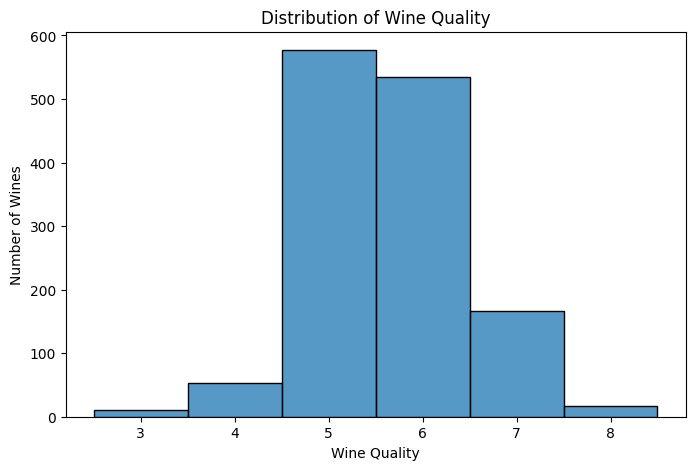

In [21]:
plt.figure(figsize=(8,5))

sns.histplot(df_clean["quality"], bins=6, discrete=True)

plt.title("Distribution of Wine Quality")
plt.xlabel("Wine Quality")
plt.ylabel("Number of Wines")
plt.show()

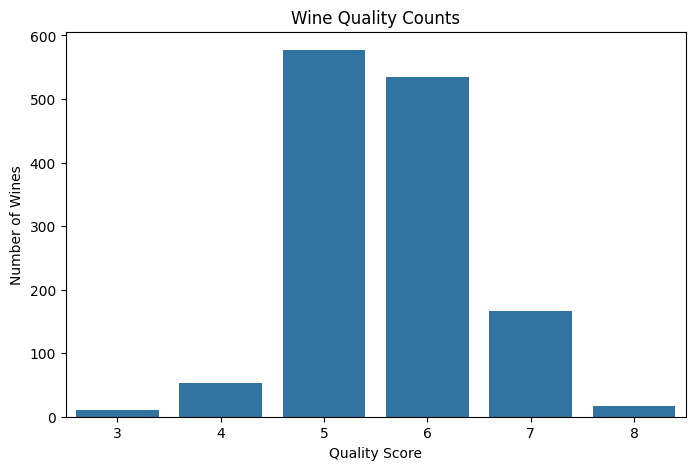

In [22]:
plt.figure(figsize=(8,5))

sns.countplot(x="quality", data=df_clean)

plt.title("Wine Quality Counts")
plt.xlabel("Quality Score")
plt.ylabel("Number of Wines")
plt.show()

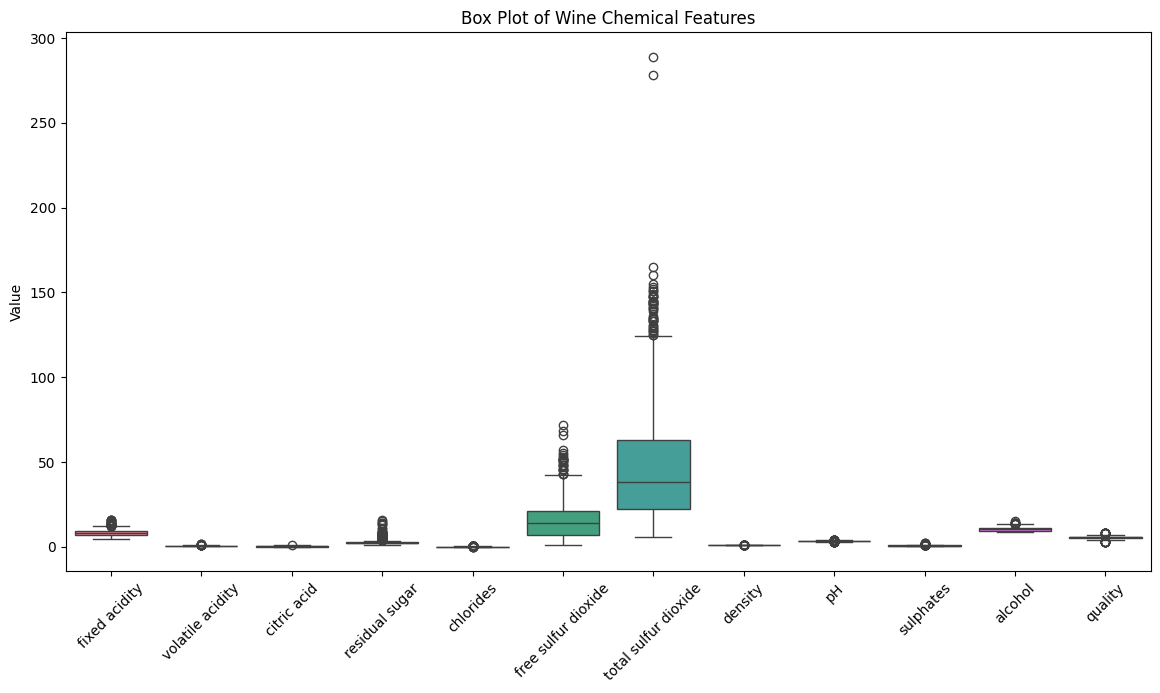

In [23]:
plt.figure(figsize=(14,7))

sns.boxplot(data=df_clean)

plt.title("Box Plot of Wine Chemical Features")
plt.xticks(rotation=45)
plt.ylabel("Value")
plt.show()

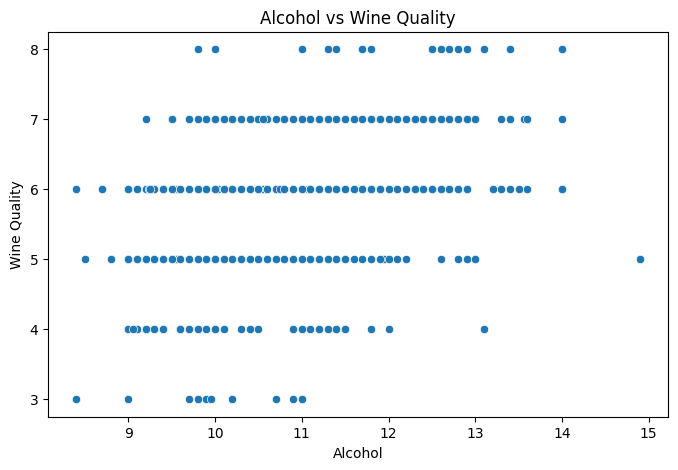

In [24]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="alcohol",
    y="quality",
    data=df_clean
)

plt.title("Alcohol vs Wine Quality")
plt.xlabel("Alcohol")
plt.ylabel("Wine Quality")
plt.show()

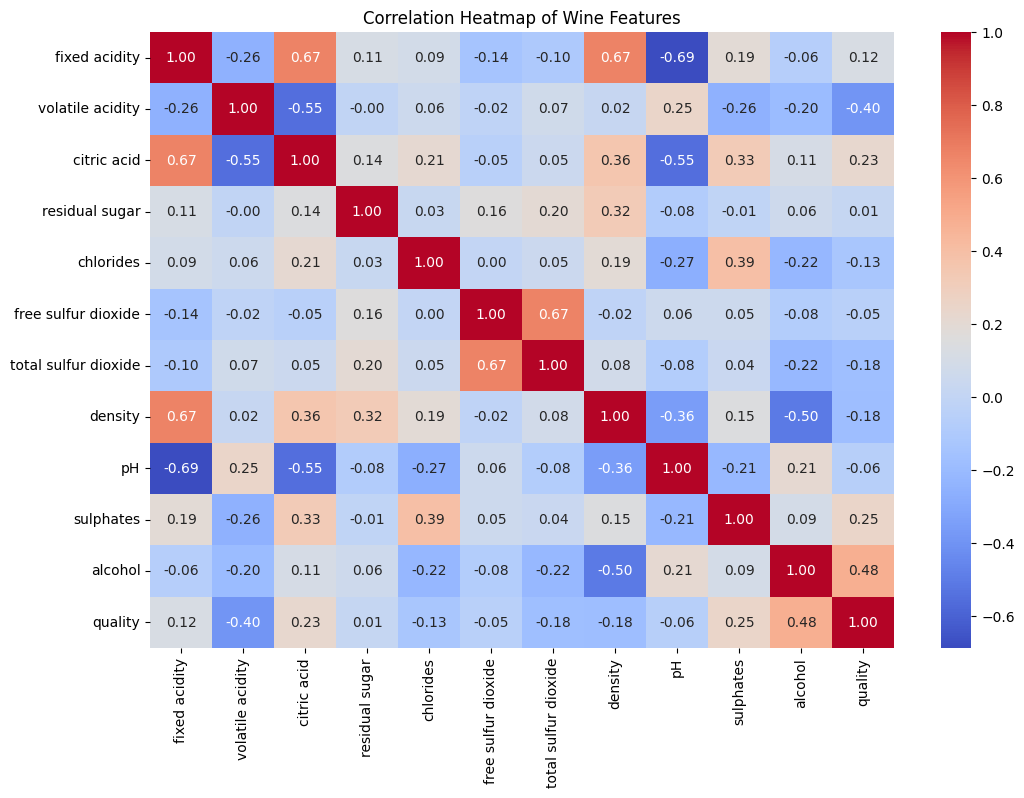

In [25]:
plt.figure(figsize=(12,8))

correlation = df_clean.corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Wine Features")
plt.show()

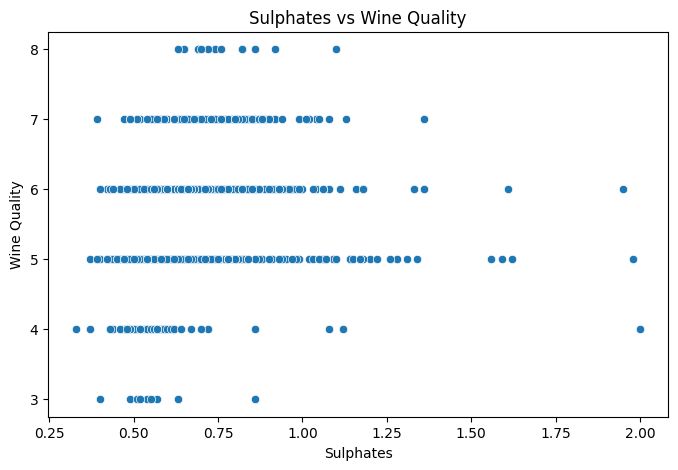

In [26]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="sulphates",
    y="quality",
    data=df_clean
)

plt.title("Sulphates vs Wine Quality")
plt.xlabel("Sulphates")
plt.ylabel("Wine Quality")
plt.show()

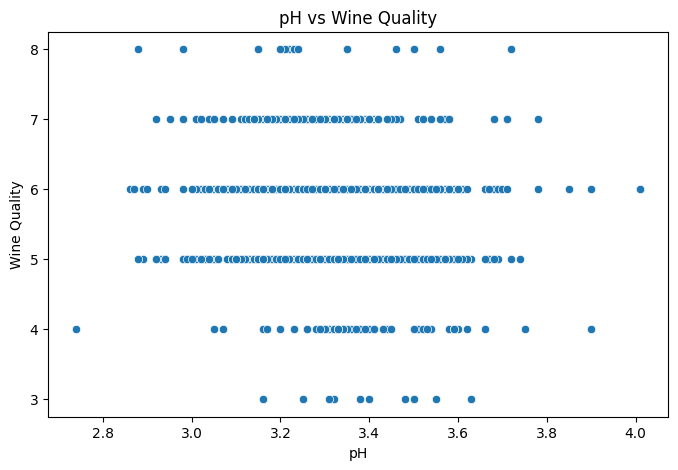

In [27]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="pH",
    y="quality",
    data=df_clean
)

plt.title("pH vs Wine Quality")
plt.xlabel("pH")
plt.ylabel("Wine Quality")
plt.show()

In [28]:
plt.savefig("wine_quality_plot.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [29]:
print("Target variable:")
print("quality")

Target variable:
quality


In [30]:
X = df_clean.drop("quality", axis=1)
y = df_clean["quality"]

print("Input features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

Input features:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']

Target:
quality


In [31]:
quality_correlation = df_clean.corr()["quality"].sort_values(ascending=False)

print(quality_correlation)

quality                 1.000000
alcohol                 0.480343
sulphates               0.248835
citric acid             0.228057
fixed acidity           0.119024
residual sugar          0.013640
free sulfur dioxide    -0.050463
pH                     -0.055245
chlorides              -0.130988
total sulfur dioxide   -0.177855
density                -0.184252
volatile acidity       -0.395214
Name: quality, dtype: float64


In [32]:
print("Number of input features:", X.shape[1])
print("Number of samples:", X.shape[0])

print("\nFeature names:")
for feature in X.columns:
    print("-", feature)

Number of input features: 11
Number of samples: 1359

Feature names:
- fixed acidity
- volatile acidity
- citric acid
- residual sugar
- chlorides
- free sulfur dioxide
- total sulfur dioxide
- density
- pH
- sulphates
- alcohol


In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 1087
Testing samples: 272


In [34]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (1087, 11)
X_test : (272, 11)
y_train: (1087,)
y_test : (272,)


In [35]:
scaler = StandardScaler()

In [36]:
X_train_scaled = scaler.fit_transform(X_train)

In [37]:
X_test_scaled = scaler.transform(X_test)

In [40]:
print("Scaled training data shape:", X_train_scaled.shape)
print("Scaled testing data shape:", X_test_scaled.shape)

Scaled training data shape: (1087, 11)
Scaled testing data shape: (272, 11)


In [41]:
print("Training feature means:")
print(X_train_scaled.mean(axis=0))

print("\nTraining feature standard deviations:")
print(X_train_scaled.std(axis=0))

Training feature means:
[ 3.57886061e-16 -1.14392805e-16 -4.57571219e-17 -2.61469268e-17
  8.33433292e-17 -1.47076463e-17  1.30734634e-17 -9.97505257e-15
 -3.01997005e-15 -4.11814097e-16 -8.87361328e-16]

Training feature standard deviations:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [42]:
ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train_scaled, y_train)

ridge_predictions = ridge_model.predict(X_test_scaled)

print("Ridge Regression model trained successfully.")

Ridge Regression model trained successfully.


In [43]:
lasso_model = Lasso(alpha=0.1)

lasso_model.fit(X_train_scaled, y_train)

lasso_predictions = lasso_model.predict(X_test_scaled)

print("Lasso Regression model trained successfully.")

Lasso Regression model trained successfully.


In [44]:
elastic_model = ElasticNet(alpha=0.1, l1_ratio=0.5)

elastic_model.fit(X_train_scaled, y_train)

elastic_predictions = elastic_model.predict(X_test_scaled)

print("Elastic Net Regression model trained successfully.")

Elastic Net Regression model trained successfully.


In [45]:
print("First 10 predictions:")
print("\nRidge:")
print(ridge_predictions[:10])

print("\nLasso:")
print(lasso_predictions[:10])

print("\nElastic Net:")
print(elastic_predictions[:10])

First 10 predictions:

Ridge:
[5.24527006 5.80905057 6.36731031 5.15914336 5.20054564 6.77555683
 5.70614104 4.84433152 5.79949998 5.73742757]

Lasso:
[5.31999007 5.67247991 5.97043342 5.31805294 5.39297829 6.42601334
 5.66504733 5.06840702 5.82298204 5.62230723]

Elastic Net:
[5.26143595 5.68677326 6.09829758 5.28234046 5.32625297 6.55708501
 5.65103348 4.95311491 5.78913318 5.64120675]


In [46]:
comparison = pd.DataFrame({
    "Actual Quality": y_test.values,
    "Ridge Prediction": ridge_predictions,
    "Lasso Prediction": lasso_predictions,
    "Elastic Net Prediction": elastic_predictions
})

comparison.head(10)

,Actual Quality,Ridge Prediction,Lasso Prediction,Elastic Net Prediction
0,5,5.245270,5.319990,5.261436
1,6,5.809051,5.672480,5.686773
2,7,6.367310,5.970433,6.098298
3,5,5.159143,5.318053,5.282340
4,4,5.200546,5.392978,5.326253
5,7,6.775557,6.426013,6.557085
6,5,5.706141,5.665047,5.651033
7,5,4.844332,5.068407,4.953115
8,6,5.799500,5.822982,5.789133
9,5,5.737428,5.622307,5.641207


In [47]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Ridge": ridge_model.coef_,
    "Lasso": lasso_model.coef_,
    "Elastic Net": elastic_model.coef_
})

coefficients

,Feature,Ridge,Lasso,Elastic Net
0,fixed acidity,-0.047756,0.000000,0.000000
1,volatile acidity,-0.178297,-0.146464,-0.165569
2,citric acid,-0.018957,0.000000,0.000000
3,residual sugar,-0.004703,-0.000000,0.000000
4,chlorides,-0.115706,-0.000000,-0.022977
5,free sulfur dioxide,0.048473,-0.000000,-0.000000
6,total sulfur dioxide,-0.123306,-0.000000,-0.039602
7,density,0.040202,-0.000000,-0.000000
8,pH,-0.120306,-0.000000,-0.013450
9,sulphates,0.148547,0.029184,0.078058


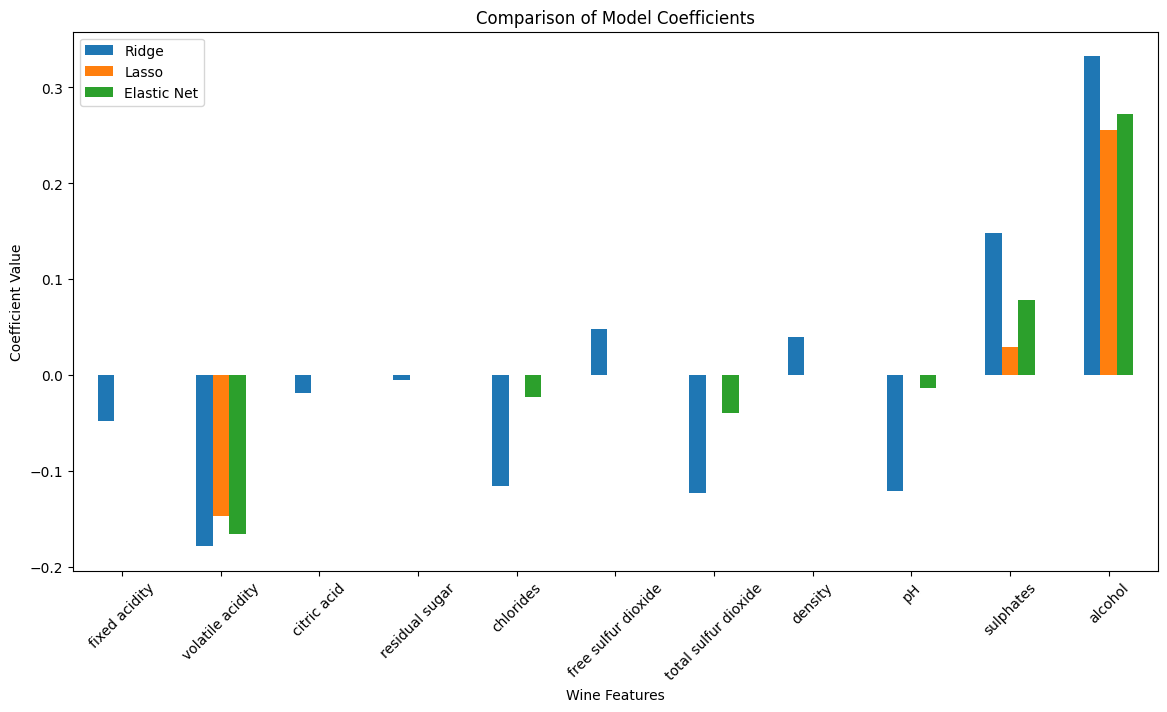

In [48]:
coefficients.set_index("Feature").plot(
    kind="bar",
    figsize=(14,7)
)

plt.title("Comparison of Model Coefficients")
plt.xlabel("Wine Features")
plt.ylabel("Coefficient Value")
plt.xticks(rotation=45)
plt.legend()
plt.show()

In [49]:
ridge_mae = mean_absolute_error(y_test, ridge_predictions)
ridge_mse = mean_squared_error(y_test, ridge_predictions)
ridge_rmse = np.sqrt(ridge_mse)
ridge_r2 = r2_score(y_test, ridge_predictions)

print("Ridge Regression")
print("MAE :", ridge_mae)
print("MSE :", ridge_mse)
print("RMSE:", ridge_rmse)
print("R²   :", ridge_r2)

Ridge Regression
MAE : 0.5040909797091884
MSE : 0.4308307459411158
RMSE: 0.6563769846217308
R²   : 0.3917877018774685


In [50]:
lasso_mae = mean_absolute_error(y_test, lasso_predictions)
lasso_mse = mean_squared_error(y_test, lasso_predictions)
lasso_rmse = np.sqrt(lasso_mse)
lasso_r2 = r2_score(y_test, lasso_predictions)

print("Lasso Regression")
print("MAE :", lasso_mae)
print("MSE :", lasso_mse)
print("RMSE:", lasso_rmse)
print("R²   :", lasso_r2)

Lasso Regression
MAE : 0.540202769671927
MSE : 0.4662343687879644
RMSE: 0.6828135681047678
R²   : 0.3418077062146515


In [51]:
elastic_mae = mean_absolute_error(y_test, elastic_predictions)
elastic_mse = mean_squared_error(y_test, elastic_predictions)
elastic_rmse = np.sqrt(elastic_mse)
elastic_r2 = r2_score(y_test, elastic_predictions)

print("Elastic Net Regression")
print("MAE :", elastic_mae)
print("MSE :", elastic_mse)
print("RMSE:", elastic_rmse)
print("R²   :", elastic_r2)

Elastic Net Regression
MAE : 0.515854409874226
MSE : 0.4395805368100759
RMSE: 0.6630087004030006
R²   : 0.3794354487882028


In [52]:
results = pd.DataFrame({
    "Model": [
        "Ridge Regression",
        "Lasso Regression",
        "Elastic Net Regression"
    ],
    "MAE": [
        ridge_mae,
        lasso_mae,
        elastic_mae
    ],
    "MSE": [
        ridge_mse,
        lasso_mse,
        elastic_mse
    ],
    "RMSE": [
        ridge_rmse,
        lasso_rmse,
        elastic_rmse
    ],
    "R2 Score": [
        ridge_r2,
        lasso_r2,
        elastic_r2
    ]
})

results

,Model,MAE,MSE,RMSE,R2 Score
0,Ridge Regression,0.504091,0.430831,0.656377,0.391788
1,Lasso Regression,0.540203,0.466234,0.682814,0.341808
2,Elastic Net Regression,0.515854,0.439581,0.663009,0.379435


In [53]:
results.round(4)

,Model,MAE,MSE,RMSE,R2 Score
0,Ridge Regression,0.5041,0.4308,0.6564,0.3918
1,Lasso Regression,0.5402,0.4662,0.6828,0.3418
2,Elastic Net Regression,0.5159,0.4396,0.6630,0.3794


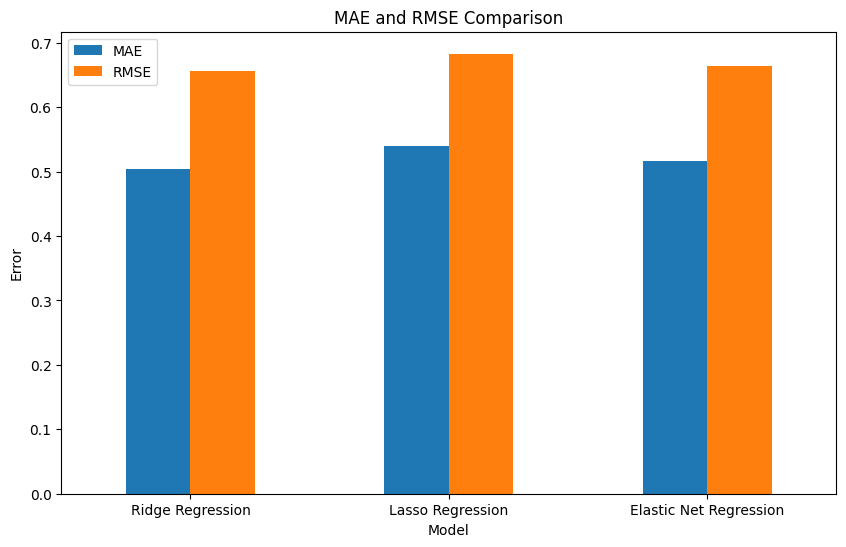

In [54]:
results_plot = results.set_index("Model")

results_plot[["MAE", "RMSE"]].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("MAE and RMSE Comparison")
plt.xlabel("Model")
plt.ylabel("Error")
plt.xticks(rotation=0)
plt.legend()
plt.show()

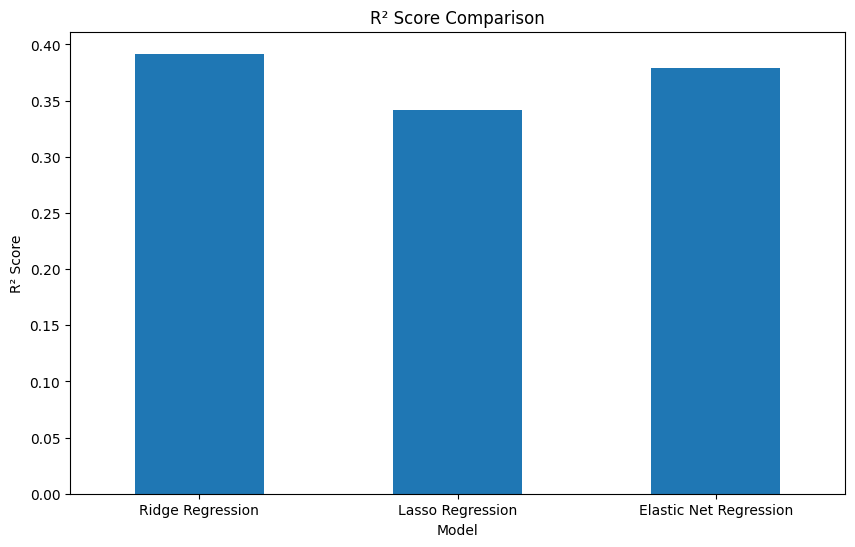

In [55]:
results_plot["R2 Score"].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("R² Score Comparison")
plt.xlabel("Model")
plt.ylabel("R² Score")
plt.xticks(rotation=0)
plt.show()

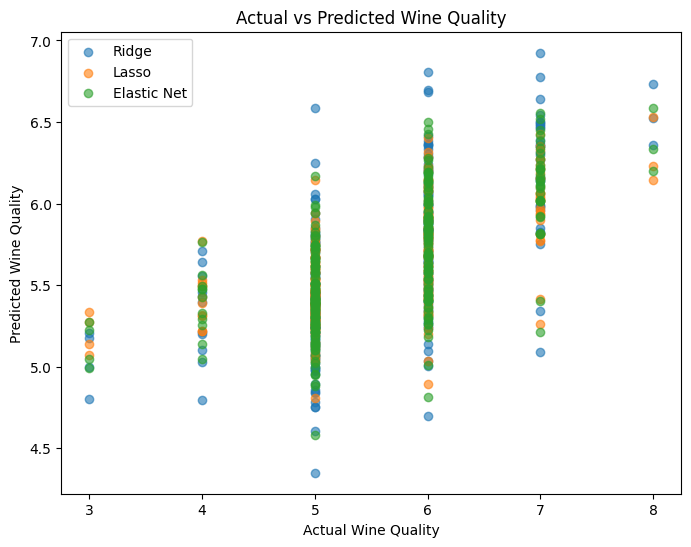

In [56]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, ridge_predictions, alpha=0.6, label="Ridge")
plt.scatter(y_test, lasso_predictions, alpha=0.6, label="Lasso")
plt.scatter(y_test, elastic_predictions, alpha=0.6, label="Elastic Net")

plt.xlabel("Actual Wine Quality")
plt.ylabel("Predicted Wine Quality")
plt.title("Actual vs Predicted Wine Quality")
plt.legend()
plt.show()

In [57]:
best_model_name = results.loc[results["RMSE"].idxmin(), "Model"]

print("Model with lowest RMSE:")
print(best_model_name)

Model with lowest RMSE:
Ridge Regression


In [58]:
if best_model_name == "Ridge Regression":
    final_model = ridge_model

elif best_model_name == "Lasso Regression":
    final_model = lasso_model

else:
    final_model = elastic_model

print("Final model selected:", best_model_name)

Final model selected: Ridge Regression


In [59]:
import joblib

In [60]:
joblib.dump(final_model, "wine_quality_model.pkl")

print("Final model saved successfully.")

Final model saved successfully.


In [61]:
joblib.dump(scaler, "wine_quality_scaler.pkl")

print("Scaler saved successfully.")

Scaler saved successfully.


In [63]:
import os

print("Model file exists:", os.path.exists("wine_quality_model.pkl"))
print("Scaler file exists:", os.path.exists("wine_quality_scaler.pkl"))

Model file exists: True
Scaler file exists: True


In [64]:
loaded_model = joblib.load("wine_quality_model.pkl")
loaded_scaler = joblib.load("wine_quality_scaler.pkl")

print("Model and scaler loaded successfully.")

Model and scaler loaded successfully.


In [65]:
sample_data = X_test.iloc[[0]]

sample_scaled = loaded_scaler.transform(sample_data)

sample_prediction = loaded_model.predict(sample_scaled)

print("Actual quality:", y_test.iloc[0])
print("Predicted quality:", sample_prediction[0])

Actual quality: 5
Predicted quality: 5.2452700567762545


In [67]:
import joblib

loaded_model = joblib.load("wine_quality_model.pkl")
loaded_scaler = joblib.load("wine_quality_scaler.pkl")

print("Model and scaler loaded successfully.")

Model and scaler loaded successfully.


In [68]:
sample_data = X_test.iloc[[0]]

sample_scaled = loaded_scaler.transform(sample_data)

sample_prediction = loaded_model.predict(sample_scaled)

print("Actual quality:", y_test.iloc[0])
print("Predicted quality:", sample_prediction[0])

Actual quality: 5
Predicted quality: 5.2452700567762545


In [69]:
%%writefile app.py

import streamlit as st
import pandas as pd
import joblib

# Load model and scaler
model = joblib.load("wine_quality_model.pkl")
scaler = joblib.load("wine_quality_scaler.pkl")

st.set_page_config(
    page_title="Wine Quality Prediction",
    page_icon="🍷",
    layout="centered"
)

st.title("🍷 Wine Quality Prediction")
st.write("Enter the chemical properties of the wine to predict its quality.")

st.subheader("Wine Chemical Properties")

fixed_acidity = st.number_input("Fixed Acidity", value=7.4)
volatile_acidity = st.number_input("Volatile Acidity", value=0.70)
citric_acid = st.number_input("Citric Acid", value=0.00)
residual_sugar = st.number_input("Residual Sugar", value=1.9)
chlorides = st.number_input("Chlorides", value=0.076)
free_sulfur_dioxide = st.number_input("Free Sulfur Dioxide", value=11.0)
total_sulfur_dioxide = st.number_input("Total Sulfur Dioxide", value=34.0)
density = st.number_input("Density", value=0.9978)
ph = st.number_input("pH", value=3.51)
sulphates = st.number_input("Sulphates", value=0.56)
alcohol = st.number_input("Alcohol", value=9.4)

if st.button("Predict Wine Quality"):

    input_data = pd.DataFrame({
        "fixed acidity": [fixed_acidity],
        "volatile acidity": [volatile_acidity],
        "citric acid": [citric_acid],
        "residual sugar": [residual_sugar],
        "chlorides": [chlorides],
        "free sulfur dioxide": [free_sulfur_dioxide],
        "total sulfur dioxide": [total_sulfur_dioxide],
        "density": [density],
        "pH": [ph],
        "sulphates": [sulphates],
        "alcohol": [alcohol]
    })

    input_scaled = scaler.transform(input_data)

    prediction = model.predict(input_scaled)[0]

    st.success(f"Predicted Wine Quality: {prediction:.2f}")

Writing app.py


In [72]:
!pip install -q streamlit

In [73]:
!streamlit run app.py > /content/streamlit.log 2>&1 &

In [74]:
!wget -q -O /content/cloudflared https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
!chmod +x /content/cloudflared

In [75]:
!./cloudflared tunnel --url http://localhost:8501 --no-autoupdate > /content/tunnel.log 2>&1 &

In [76]:
!grep -o 'https://[-a-zA-Z0-9.]*trycloudflare.com' /content/tunnel.log

https://address-obligation-genealogy-smile.trycloudflare.com
